In this project the goal is to load the dataset, apply 3 different predictive models from curriculum and provide an analysis on which model is the best.




The **models** which they can use are


1.   Linear or Logistic Regression
2.   K-Nearest Neighbors(KNN)
3.   Naive Bayes
4. Decision Trees
5. Ensemble methods (Random Forest)
6. Support vector machines(SVM)

The **goals** are


*   To perform the data analysis will be either classification or regression.
*   Implement any of 3 models using scikit- learn
* For classification: Logistic regression, KNN, Naive Bayes, Decision Trees, Ensemble
* For regression: (multiple) Linear regression, Decision Tree regression, Random forest (ensemble) etc.

(If you chose regression, then the best target variable would be 'mean radius')

*   Evaluate models using metrics as Accuracy, F1-Score, MSE etc.
*   Compare and analyse the results along with a brief summary on which model works best.


Note:- 
Implementations can be self implementations or any package such as scikit-learn. 










# **Implementation Steps:-**

**Phase 1: Data Preprocessing**

* Load the data and check for missing values.
(You can chose the breast cancer dataset/wine quality/california housing/ames housing)
* visualization of the target variable distribution.

* Perform feature scaling if required for your chosen models(KNN or SVM)


**Phase 2: Training**

* Split the data into Training(80%) and Testing (20%) sets

* Initialize and train the 3 models which you have chosen.


**Phase 3: Evaluation and visualization**

* For each model, generate a performance report.

* For classification : plot a confusion matrix.

* For regression : plot predicted vs Actual values.

**Phase4: Reporting**

provide a brief summary at the end for the following questions

1. why did you choose these 3 specific models for this dataset?

2. which model has the highest accuracy/lowest error?

3. Did any model overfit ?(which means high training score but low test score)

4. Which model works best and why ?

# Grading Rubric

* Data cleaning - 20 points
* Model 1 Implementation and Evaluation - 20 points
* Model 2 Implementation and Evaluation - 20 points
* Model 3 Implementation and Evaluation - 20 points
* Comparative Analysis and conclusion - 20 points

Submission Instructions:- Please do submit the results in the Jupyter Notebook and analysis and reports within the markdown.
***Note :- Any use of AI is not permitted, if found, it would be reported.***

# **Conclusion and Analysis**
**Phase 1: Data Preprocessing**


I chose the sklearn breast cancer dataset for this project, and chose to make classification models. Data was standardized using StandardScaler for better model performance. The target variable was categorical, 0 for a malignant tumor and 1 for a benign tumor. Below is a bar chart to visualize the distribution of values.

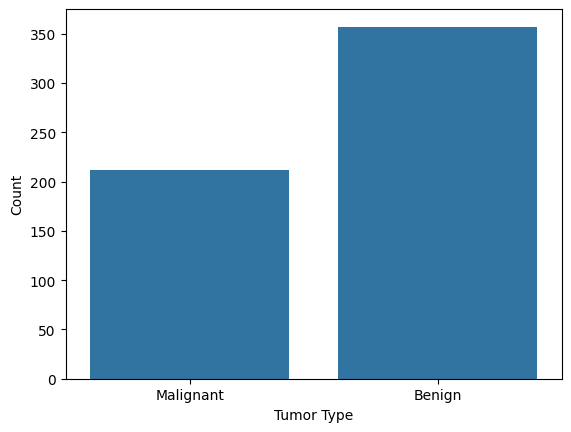

As you can see, benign tumors are more common in the dataset. However, there are still a significant number of malignant tumors.

**Phase 2: Training**

The 3 models I selected are logistic regression, classification tree, and random forest. There was a 20/80 training/testing split.

**Phase 3: Evaluation and visualization**

Each model's performance was evaluated using its prediction accuracy, accuracy difference with testing and training sets, and its cross validation score. The CV mean shows the model's accuracy over repeated prediction trials, and the standard deviation shows its variability in accuracy between them. The confusion matrix shows the number of correct predictions, as well as false-positives and false-negatives.

In [41]:
import models
def performanceReport(model_name, accuracy, train_accuracy, cv, cm):
    print(f"Prediction Accuracy: {accuracy:.2%}")
    print(f"Accuracy Difference between Test and Training Data: {accuracy - train_accuracy:.2%}")
    print(f"Cross-Validation Score (Mean): {cv.mean():.2%}")
    print(f"CV Variability (Standard Deviation): {cv.std():.4f}")
    cm.plot()
    cm.ax_.set_title(model_name + " Confusion Matrix")
    return

*<u>Model 1</u> - Logistic Regression*

Prediction Accuracy: 97.37%
Accuracy Difference between Test and Training Data: -1.31%
Cross-Validation Score (Mean): 97.58%
CV Variability (Standard Deviation): 0.0146


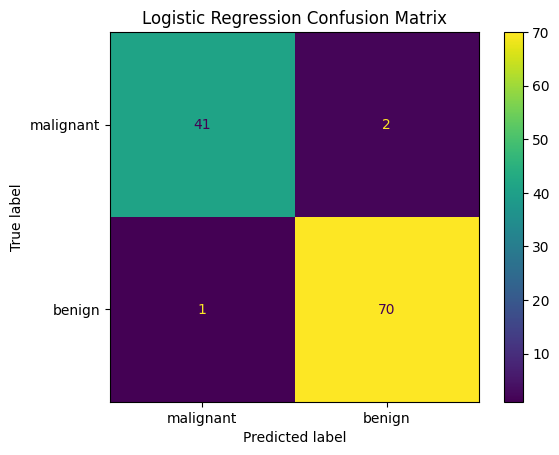

In [42]:
performanceReport("Logistic Regression", models.logreg_accuracy, models.logreg_train_accuracy, models.logreg_cv_scores, models.lg_cm_disp)

*<u>Model 2</u> - Classification Tree*

Prediction Accuracy: 93.86%
Accuracy Difference between Test and Training Data: -6.14%
Cross-Validation Score (Mean): 91.87%
CV Variability (Standard Deviation): 0.0226


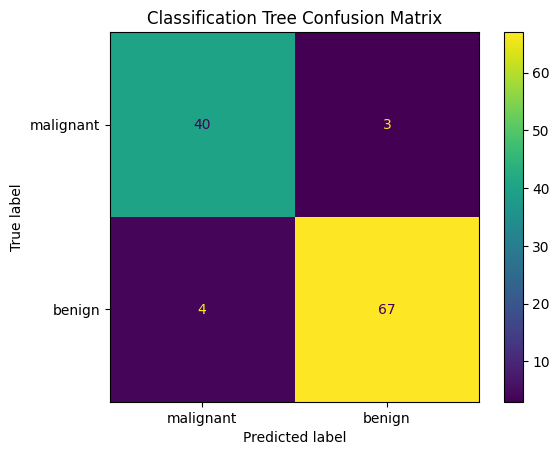

In [43]:
performanceReport("Classification Tree", models.tree_accuracy, models.tree_train_accuracy, models.tree_cv_scores, models.tree_cm_disp)

*<u>Model 3</u> - Random Forest*

Prediction Accuracy: 96.49%
Accuracy Difference between Test and Training Data: -3.51%
Cross-Validation Score (Mean): 96.04%
CV Variability (Standard Deviation): 0.0149


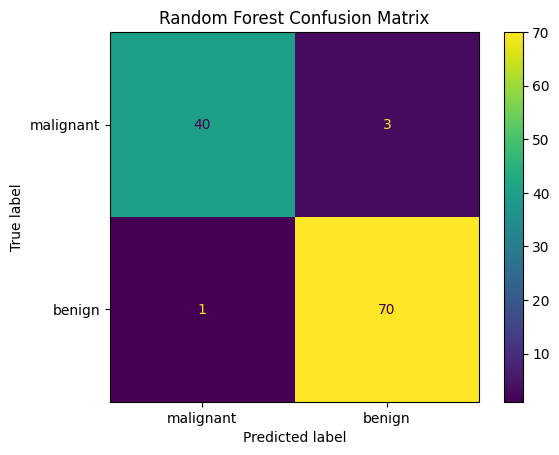

In [44]:
performanceReport("Random Forest", models.rf_accuracy, models.rf_train_accuracy, models.rf_cv_scores, models.rf_cm_disp)

**Phase 4: Reporting**

> 1. Why did you choose these 3 specific models for this dataset?

Firstly, logistic regression was used because I was predicting a binary classification (malignant or benign). It's the most straight forward model and very interpretable. They're best for independent variables. I then used a classification tree as they're the next simplest to implement and interpretable, as well as being one of the models most used for medical diagnoses. These models are best for dependent or connected variables. My third and final model, the random forest, was chosen for the same reasons as the tree, except it provided higher accuracy and less chance of overfitting to noise or randomness than the previous model.

> 2. Which model has the highest accuracy/lowest error?

I used accuracy as my indicator of success for evaluating my models. With this, the most successful model (highest accuracy) is the  logistic regression model with a 97.37% predictive accuracy.

> 3. Did any model overfit ?(which means high training score but low test score)

None of them were extremely overfit, but the model that was trained the most on the noise was the classification tree. It had a 6.14% difference in predictive accuracy in the training set versus testing set. This is roughly 2x higher than the next closest difference, which was the random forest model. This implies there was some level of overfitting, which is common for classification trees, especially those trained on all variables.

> 4. Which model works best and why ?

Overall, the best model would be the logistic regression since it had the highest prediction accuracy and mean cross validation score, as well as the lowest difference in training vs testing accuracy and variation in cross validation scores. This means it performed the best across all 4 indicators. The success of linear regression suggests that the relationship between the variables is close to linear and the full set of variables contains noise that random forest and decision trees would be more sensitive to.

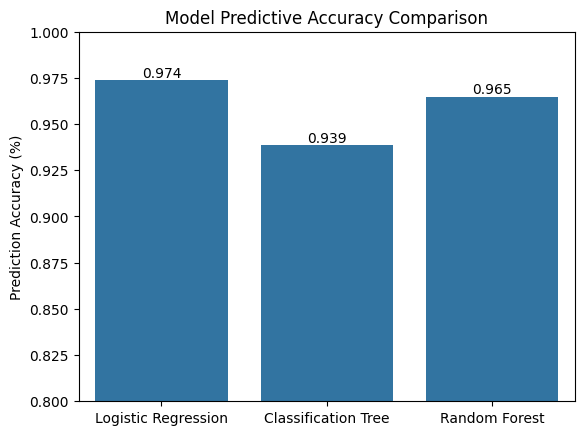

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
fig1 = sns.barplot(x=["Logistic Regression", "Classification Tree", "Random Forest"], y=[models.logreg_accuracy, models.tree_accuracy, models.rf_accuracy])
plt.ylabel("Prediction Accuracy (%)")
plt.title("Model Predictive Accuracy Comparison")
plt.ylim(0.8, 1.0)
for container in fig1.containers:
    fig1.bar_label(container, fmt='%.3f')
plt.show()

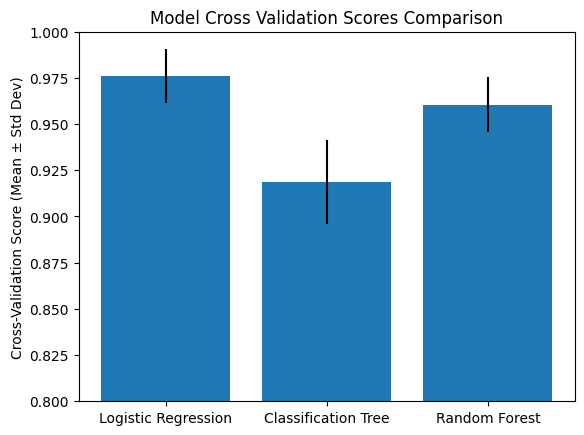

In [77]:
plt.bar(["Logistic Regression", "Classification Tree", "Random Forest"], height=[models.logreg_cv_scores.mean(), models.tree_cv_scores.mean(), models.rf_cv_scores.mean()], yerr=[models.logreg_cv_scores.std(), models.tree_cv_scores.std(), models.rf_cv_scores.std()])
plt.ylabel("Cross-Validation Score (Mean ± Std Dev)")
plt.title("Model Cross Validation Scores Comparison")
plt.ylim(0.8, 1.0)
plt.show()